<hr style="height:1px; background-color:black; border:none;">

# Mini Project 3 - Amazon Reviews on Toys & Games

By Daniel Li

<hr style="height:1px; background-color:black; border:none;">

### **Overview**
This mini project utilises a dataset pulled from Huggingface an export of Amazon reviews in the category of Toys & games from 1996 to 2023. The data set contains over 16million reviews which we will sample 20,000 for the review.
</br></br>
Both a text sentiment and a rating is provided with additional columns like reviewer, product IDs to usefulness and timestamps. We will use a supervised learning model and text classifiers to assist in analysing the data.

### **Question**
How well does review text predict customer satisfaction/rating?

### **Business cases**
Star rating alone lacks context, by predicting text sentiment we can identify potential misleading star ratings and also utilise the text components to have a far better picture of sentiment. i.e products may have an inflated 5 star review

- Prevent Trust erosion
- Churn risk of customers
- Product issues or complaints

## Library imports

In [1]:
import pandas as pd                       # Pandas library
import numpy as np                        # Numpy Library
import seaborn as sns                     # Seaborn
import matplotlib.pyplot as plt           # Matplot plots
from pathlib import Path                  # Path plot
import duckdb                             # A library that lets you preview a JSONL file without loading to RAM and inspects using the disk.
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


import regex as re
from bs4 import BeautifulSoup
import contractions
import spacy
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textstat import textstat
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix,classification_report, accuracy_score, precision_score, recall_score, average_precision_score, roc_auc_score, precision_recall_curve, roc_curve, auc, f1_score, precision_recall_fscore_support,ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


#SNS pallete style referencing powerpoint

# Slide colour palette (dark → light)
SLIDE_PALETTE = ["#353552", "#6875a7", "#6abec5", "#afe0d9"]

sns.set_palette(SLIDE_PALETTE)
slide_palette = sns.color_palette(SLIDE_PALETTE)
slide_cmap = LinearSegmentedColormap.from_list(
    "slide_cmap",
    SLIDE_PALETTE
)

# Text Preprocessing
In this step I wanted to review the entire dataset understand how many total observations. what was the high level distribution of the data.


## SAMPLE 100K from the original dataset

In [2]:
df = duckdb.query("""
    SELECT *
    FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
    USING SAMPLE 100000
""").df()

df.info()
display(df.describe())
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   rating             100000 non-null  float64
 1   title              100000 non-null  object 
 2   text               100000 non-null  object 
 3   images             100000 non-null  object 
 4   asin               100000 non-null  object 
 5   parent_asin        100000 non-null  object 
 6   user_id            100000 non-null  object 
 7   timestamp          100000 non-null  int64  
 8   helpful_vote       100000 non-null  int64  
 9   verified_purchase  100000 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 7.0+ MB


,rating,timestamp,helpful_vote
count,100000.000000,1.000000e+05,100000.000000
mean,4.210170,1.552203e+12,0.820800
std,1.337594,9.255909e+10,6.814014
min,1.000000,9.706052e+11,0.000000
25%,4.000000,1.485653e+12,0.000000
50%,5.000000,1.571960e+12,0.000000
75%,5.000000,1.623950e+12,0.000000
max,5.000000,1.694127e+12,1106.000000


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,"suction cups suck (or rather, they don't suck ...",Tons of fun to play with! I purchased the set...,[],B07RN2CC7J,B07RN2CC7J,AGS5DUYNS5KDNXQL2ZCE5SSOTFIQ,1597158420252,0,True
1,5.0,Awesome gift for kids and adults young-at-heart,Big hit at Christmas time. Everyone loved them...,[],B003KCG9IM,B003KCG9IM,AG4CCGAIRQ2WQUIAJJ3DDDX6JAVA,1431927033000,0,True
2,5.0,Five Stars,Nice set!,[],B00JYGP0JM,B0BMM9B872,AHQQSV6GLUMAKGY77FS522A6ZA2A,1500931820629,0,True


# High level of entire Dataset

### Total Observations

In [3]:
# check how many obervations are aviable in this data set.
total_rows = duckdb.query("""
    SELECT printf('%,d', COUNT(*)) AS total_rows
    FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
""").df()

total_rows

,total_rows
0,"16,260,406"


### Check reviews per user id

In [4]:
userid_ucount = duckdb.query("""
    WITH user_counts AS (
    SELECT
        user_id,
        COUNT(*) AS occurrence_count
    FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
    WHERE user_id IS NOT NULL
    GROUP BY user_id
)
SELECT
    user_id,
    occurrence_count,
    ROUND(
        occurrence_count * 100.0 / SUM(occurrence_count) OVER (),
        2
    ) AS percent_of_total
FROM user_counts
ORDER BY occurrence_count DESC;
    
""").df()

userid_ucount.head(10)

,user_id,occurrence_count,percent_of_total
0,AGZZXSMMS4WRHHJRBUJZI4FZDHKQ,2954,0.02
1,AG375WAXLZ7PIOQKIQ6KQB4J3JVQ,1120,0.01
2,AG73BVBKUOH22USSFJA5ZWL7AKXA,1042,0.01
3,AEIIRIHLIYKQGI7ZOCIJTRDF5NPQ,1022,0.01
4,AEXGISIVX7WBUNI7UHHERVB3DF7Q,866,0.01
5,AFPF2CONJ33FNFKOEQ2TUNWQJTFQ,721,0.00
6,AFFNI6O4TK5UFNWJVDTCOUQAO2UA,661,0.00
7,AGUTZC4GHLTGYHA3KBEDRF6MHB6A,633,0.00
8,AFTZWAK3ZHAPCNSOT5GCKQDECBTQ,616,0.00
9,AEHZBUFEOW4TY3K4IYFFR5ZU5B3Q,597,0.00


### check unique counts of parent_asin and the percentage distribution to entire dataset.

In [5]:
# query to check the count and distribtion of unique ASIN
parent_asin_ucount = duckdb.query("""
    WITH parent_counts AS (
    SELECT
        parent_asin,
        COUNT(*) AS occurrence_count
    FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
    WHERE parent_asin IS NOT NULL
    GROUP BY parent_asin
)
SELECT
    parent_asin,
    occurrence_count,
    ROUND(
        occurrence_count * 100.0 / SUM(occurrence_count) OVER (),
        2
    ) AS percent_of_total
FROM parent_counts
ORDER BY occurrence_count DESC;
    
""").df()

parent_asin_ucount.head(10)

,parent_asin,occurrence_count,percent_of_total
0,B004S8F7QM,18698,0.11
1,B0054TRQA4,13303,0.08
2,B0C3H818H4,11638,0.07
3,B0BW3QTWJJ,11357,0.07
4,B07N29HQMN,9769,0.06
5,B07DLJFQ5Z,8214,0.05
6,B07C4NGT17,7590,0.05
7,B0BSXDB363,6953,0.04
8,B0BFXK2HJW,6741,0.04
9,B0BDXWGW31,6441,0.04


## See rating distribution of entire DB

In [6]:
query = """
WITH rating_counts AS (
    SELECT 
        rating,
        COUNT(*) AS count
    FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
    GROUP BY rating
)
SELECT
    rating,
    count,
    ROUND(count * 100.0 / SUM(count) OVER (), 2) AS percent
FROM rating_counts
ORDER BY rating
"""

rating_dist = duckdb.query(query).df()
rating_dist

,rating,count,percent
0,1.0,1631131,10.03
1,2.0,767908,4.72
2,3.0,1103648,6.79
3,4.0,1797010,11.05
4,5.0,10960709,67.41


#### **Observation**
Majority of the reviews comes from 5 star ratings. We would likely combine rating 4-5 as the positive reviews and 3-1 as negative reviews. which gives us a split of 21.54% for negative and 78.46% for positive.


# Creating the working database

## Pull samples based on above % distribution of entire DB create a DF

In [7]:
# Pull 20,000 rows using the above percentage distribution
'''
query = """
WITH targets(rating, target_n) AS (
  VALUES
    (1.0, 2006),
    (2.0,  944),
    (3.0, 1358),
    (4.0, 2210),
    (5.0, 13482)
),
base AS (
  SELECT
    *
  FROM read_json_auto('DataSet/Toys_and_Games.jsonl')
),
ranked AS (
  SELECT
    b.*,
    ROW_NUMBER() OVER (PARTITION BY b.rating ORDER BY random()) AS rn
  FROM base b
)
SELECT
  r.* EXCLUDE (rn)
FROM ranked r
JOIN targets t USING (rating)
WHERE r.rn <= t.target_n;
"""

working_df = duckdb.query(query).df()

print("Shape:", working_df.shape)
print("\nRating distribution (%):")
print(
    working_df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

'''

'\nquery = """\nWITH targets(rating, target_n) AS (\n  VALUES\n    (1.0, 2006),\n    (2.0,  944),\n    (3.0, 1358),\n    (4.0, 2210),\n    (5.0, 13482)\n),\nbase AS (\n  SELECT\n    *\n  FROM read_json_auto(\'DataSet/Toys_and_Games.jsonl\')\n),\nranked AS (\n  SELECT\n    b.*,\n    ROW_NUMBER() OVER (PARTITION BY b.rating ORDER BY random()) AS rn\n  FROM base b\n)\nSELECT\n  r.* EXCLUDE (rn)\nFROM ranked r\nJOIN targets t USING (rating)\nWHERE r.rn <= t.target_n;\n"""\n\nworking_df = duckdb.query(query).df()\n\nprint("Shape:", working_df.shape)\nprint("\nRating distribution (%):")\nprint(\n    working_df["rating"]\n    .value_counts(normalize=True)\n    .sort_index()\n    .mul(100)\n    .round(2)\n)\n\n'

In [8]:
#save to csv to keep data consistent
'''
working_df.to_csv("Amazon Reviews - Sampled 20k reviews.csv", index=False)
'''


'\nworking_df.to_csv("Amazon Reviews - Sampled 20k reviews.csv", index=False)\n'

# Data Cleaning

In [9]:
# Reload dataframe from csv also renaming the working DF to amazon_df
filepath = "Amazon Reviews - Sampled 20k reviews.csv"
amazon_df = pd.read_csv(filepath)

## Quick data overview

In [10]:
# quick overview of the new dataset
display(amazon_df.shape)
display(amazon_df.info())
display(amazon_df.describe())

(20000, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             20000 non-null  float64
 1   title              19995 non-null  object 
 2   text               19994 non-null  object 
 3   images             20000 non-null  object 
 4   asin               20000 non-null  object 
 5   parent_asin        20000 non-null  object 
 6   user_id            20000 non-null  object 
 7   timestamp          20000 non-null  int64  
 8   helpful_vote       20000 non-null  int64  
 9   verified_purchase  20000 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 1.4+ MB


None

,rating,timestamp,helpful_vote
count,20000.000000,2.000000e+04,20000.000000
mean,4.210900,1.551997e+12,0.792150
std,1.337576,9.293819e+10,4.601305
min,1.000000,9.688594e+11,0.000000
25%,4.000000,1.486024e+12,0.000000
50%,5.000000,1.573420e+12,0.000000
75%,5.000000,1.623867e+12,0.000000
max,5.000000,1.693489e+12,283.000000


#### Comparison of describe to entire DB 
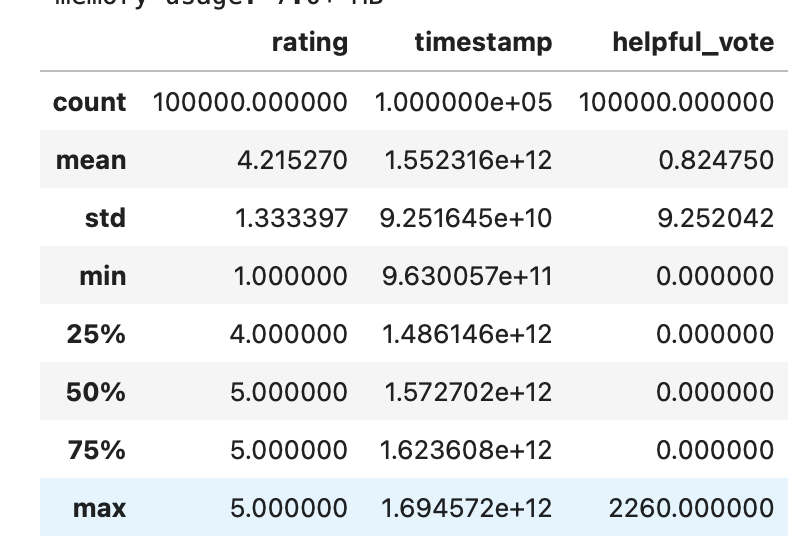

#### **Observation**
- comparison to the original DB the data looks to be a similiar distribution of reviews across rating. Which is critical for our origin al objective. Interesting to note that our std for helpful reviews has shifted but expected from taking a sample of the data from the original dataset.
- There is 6 reviews that are missing text we will drop these columns as purpose is to analyse the text component.
  


In [11]:
# Drop NaN text obersvations
amazon_df = amazon_df.dropna(subset=["text"])

In [12]:
# Convert timestamps to data time.
amazon_df["timestamp"] = pd.to_datetime(amazon_df["timestamp"], unit="ms")

In [13]:
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19994 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             19994 non-null  float64       
 1   title              19991 non-null  object        
 2   text               19994 non-null  object        
 3   images             19994 non-null  object        
 4   asin               19994 non-null  object        
 5   parent_asin        19994 non-null  object        
 6   user_id            19994 non-null  object        
 7   timestamp          19994 non-null  datetime64[ns]
 8   helpful_vote       19994 non-null  int64         
 9   verified_purchase  19994 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 1.5+ MB


In [14]:
amazon_df.describe()

,rating,timestamp,helpful_vote
count,19994.000000,19994,19994.000000
mean,4.210663,2019-03-07 20:11:21.748316928,0.792138
min,1.000000,2000-09-13 15:37:21,0.000000
25%,4.000000,2017-02-02 00:48:18.500000,0.000000
50%,5.000000,2019-11-10 21:05:58.575000064,0.000000
75%,5.000000,2021-06-16 17:23:56.198249984,0.000000
max,5.000000,2023-08-31 13:31:16.893000,283.000000
std,1.337707,NaN,4.601947


## Sample

In [15]:
amazon_df.sample(20)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
8775,5.0,My kids love it,Easy installation but rope is really short,[],B085C7KTQ1,B0BZVD5CKV,AER3EPGPBGYGYTYTDPS5E3REH66A,2021-06-17 17:25:30.272,0,True
2220,5.0,True to Ad,Looks just like the ad.,[],B09BB5TYDH,B09VGBP8Y1,AFNZ2ZUA2FH5Y3OERGK236G6ANVQ,2023-05-14 00:24:03.944,1,True
11339,5.0,Love it,Love it!,[],B07JCM53Y5,B07JCM53Y5,AH2V7AE6RMIRSW74B2UQI5MYPCBA,2019-09-23 23:56:35.912,0,True
10120,5.0,So glad I bought this!,This is adorable and my 16 month old love it!,[],B00XPH0618,B00XPH0618,AF5KPOGZ5OQB4MHE7A5WYBXH3JQA,2020-03-11 13:46:44.758,0,True
15852,3.0,"Cute, but not glued together well","Most of the bags were separated at the seams, ...",[],B08NCWV51W,B08NCWV51W,AFMT5HCPBCKTKC62SBJRG6YFLSGQ,2021-05-20 18:48:13.419,0,True
18974,1.0,Intex pools never again,We bought this pool twice this summer. The fir...,[],B000058TJ3,B0C2Q7B81W,AHAPEQEPKLSWW64Y4PLLTLG5D4VQ,2022-07-25 18:22:55.538,0,True
17375,2.0,So small my 2yearold can’t even stand to play,Poorly made<br />Small and unsturdy,[],B01N6IKSSZ,B01N6IKSSZ,AHIFZIC3OLRKUF6REYTEDSJKIE2Q,2020-07-01 01:52:06.158,0,True
8886,5.0,very cute! works with i pod.,It works well with an i pod. It lights up and ...,[],B000EYF7Q4,B000EYF7Q4,AHMYA5F7OQVT54AUVBZ5J7ILLSLQ,2013-05-15 16:57:22.000,0,True
8819,5.0,So cute!,My little Charlotte’s Web fan loved getting th...,[],B0068QUF8C,B07N29HQMN,AFD6CL5UQTDRTIMPIBPGWMMOGGXQ,2020-01-08 15:06:30.333,0,True
17048,3.0,Depends on your comfort level,This is a fun game with interesting questions....,[],B075HQSLDF,B0BM4X8G2C,AEIA5A5NH7BSX2FPCEIPBWXA5AIQ,2018-04-27 14:46:13.576,97,True


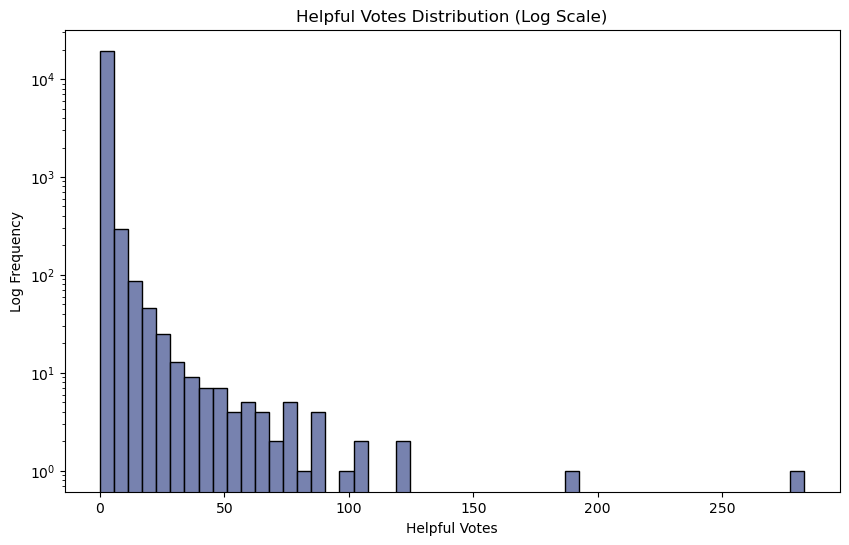

In [16]:
# Histogram of helpful distributions
plt.figure(figsize=(10, 6))

sns.histplot(
    data=amazon_df,
    x="helpful_vote",
    bins=50,
    log=True,      
    alpha=0.9,
    color="#6875a7"
)

plt.xlabel("Helpful Votes")
plt.ylabel("Log Frequency")
plt.title("Helpful Votes Distribution (Log Scale)")
plt.show()

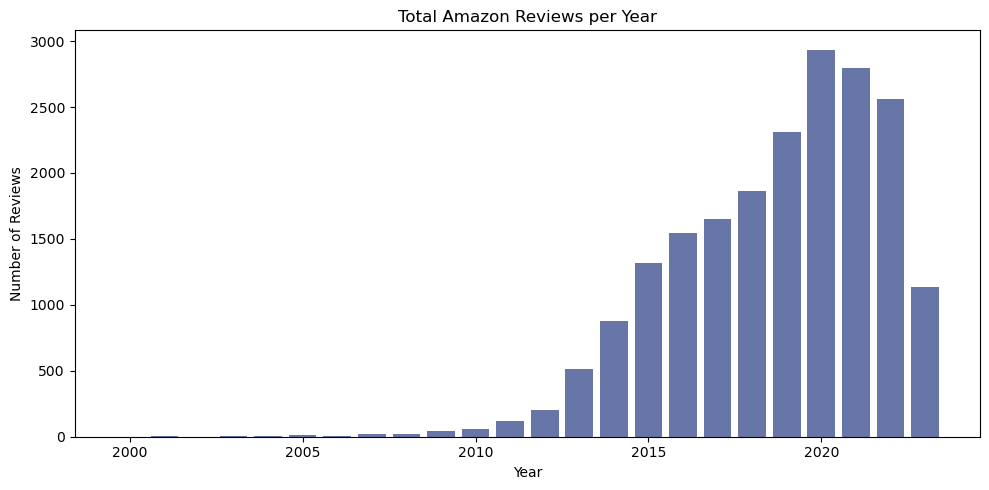

In [17]:
amazon_df["year"] = amazon_df["timestamp"].dt.year

reviews_per_year = (
    amazon_df
    .groupby("year")
    .size()
    .reset_index(name="total_reviews")
)

plt.figure(figsize=(10, 5))

plt.bar(
    reviews_per_year["year"],
    reviews_per_year["total_reviews"],
    color="#6875a7"
)

plt.title("Total Amazon Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

#### **Observation**
- helpful nots generally skew to the lower end and notable that 0 helpful votes were in a majority of the data
- Looks like majority of reviews started to grow significantly from 2011


## Share of ratings

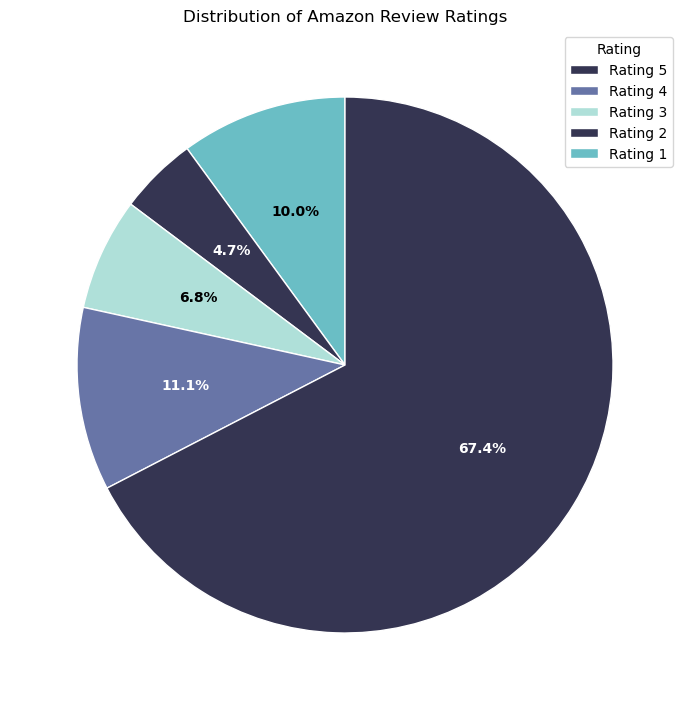

In [18]:
# 1) Counts
rating_counts = amazon_df["rating"].value_counts().sort_index()

# 2) Get your global palette (dark -> light as you defined)
pal = sns.color_palette()  # uses sns.set_palette(SLIDE_PALETTE)
# If you want to be explicit, use:
# pal = sns.color_palette(SLIDE_PALETTE)

# 3) Assign darker colours to larger slices
# rank ratings by count (descending)
order_by_size = rating_counts.sort_values(ascending=False).index.tolist()

# map largest -> pal[0] (darkest), next -> pal[1], etc. (cycles if needed)
color_map = {}
for i, r in enumerate(order_by_size):
    color_map[r] = pal[i % len(pal)]

# colors in rating order (1..5)
colors = [color_map[r] for r in rating_counts.index]

# 4) Helper: pick white/black label text based on wedge brightness
def label_color(rgb):
    r, g, b = mcolors.to_rgb(rgb)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "white" if luminance < 0.55 else "black"

def autopct_format(pct):
    return f"{pct:.1f}%"

plt.figure(figsize=(7, 10))

wedges, texts, autotexts = plt.pie(
    rating_counts.values,
    autopct=autopct_format,
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)

# style the percent labels to match wedge brightness
for w, at in zip(wedges, autotexts):
    at.set_color(label_color(w.get_facecolor()))
    at.set_weight("bold")

plt.title("Distribution of Amazon Review Ratings")

# 5) Legend
legend_elements = [
    Patch(
        facecolor=color_map[rating],
        edgecolor="white",
        label=f"Rating {int(rating)}"
    )
    for rating in sorted(rating_counts.index, reverse=True)
]

plt.legend(
    handles=legend_elements,
    title="Rating",
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()

#### **Observation**
- Share of ratings skewed heavily towards 5 star ratings.
- while for the negative reviews 1 star had the higher proportion
- we could say that amazon reviews feel strongly towards either end of the spectrum when providing star raitings.


## Merge cells

### Concatenate all text to a single column

In [19]:
#Concatenate title and text to one cell as the total review feature.
amazon_df["total_review"] = (
    amazon_df["title"].fillna("") + " " + amazon_df["text"].fillna("")
).str.strip()

In [20]:
#inspecking the DF
amazon_df

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,year,total_review
0,5.0,Perfect gift for the rock lover,I got this for my 9yr old granddaughter and it...,[],B0824HQMV8,B0B6GDTKZT,AG5PBZ3GKQCQZNYT23T3H6WACS5A,2021-09-10 16:23:18.422,1,True,2021,Perfect gift for the rock lover I got this for...
1,5.0,Five Stars,Nice!,[],B01KJKZCI0,B01KJKZCI0,AFPKQS4LQARG35LKJEESLCFNHYIQ,2018-01-08 18:07:31.525,0,True,2018,Five Stars Nice!
2,5.0,Better than before.,In the beginning I’ve had problems with the es...,[],B07K9TTQDT,B07K9TTQDT,AGZ5XY6HI6TXPUYU56OJP7Q5R25A,2019-08-05 18:54:29.242,1,True,2019,Better than before. In the beginning I’ve had ...
3,5.0,On the small side but very good paint and scul...,Very realistic frogs the paint Scheme is wonde...,[],B01LFTKL5S,B01LFTKL5S,AGKBK4FPBISL73EMESYQ5IEKZDKQ,2019-03-03 14:30:14.450,0,True,2019,On the small side but very good paint and scul...
4,5.0,Perfect for first timer,"Great quality and very durable little car,<br ...",[{'small_image_url': 'https://m.media-amazon.c...,B09TP78D17,B09TP78D17,AH3FYKSVY7TQOK7QJW6BRQTMCUQA,2022-08-03 04:43:05.546,1,True,2022,Perfect for first timer Great quality and very...
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,Poor design. Sloppy paint jobs,NO STARS!!! Worthless Junk! A leg broke off se...,[],B00WO0ADQK,B00WO0ADQK,AHEQXIGE6K4AOAPHGR47YYURGYSQ,2016-01-11 21:20:09.000,0,False,2016,Poor design. Sloppy paint jobs NO STARS!!! Wor...
19996,1.0,Didn't work 😪,The didn't work,[],B08S2X66T3,B0BRSD3YP1,AHOAT7YASHQG5UZVLZOC6I4ZQO6Q,2022-04-25 20:56:16.540,0,True,2022,Didn't work 😪 The didn't work
19997,1.0,Broke with in 5mins of my daughter playing wit...,My daughter chose this as her gift to open Chr...,[{'small_image_url': 'https://m.media-amazon.c...,B08Q7RWXBS,B089M3BXKM,AFPF5WWCGGCO7BAXO6TJ7HUFLQTQ,2021-12-25 01:16:04.268,0,True,2021,Broke with in 5mins of my daughter playing wit...
19998,1.0,False advertising,"This item only came with one ball and one car,...",[],B088GSYKV6,B093QPDBC2,AFMH3QBXBZXTHQYBH36JIJR7BICQ,2020-12-24 02:31:32.851,0,True,2020,False advertising This item only came with one...


### create a new output cell from ratings column

In [21]:
rating_map = {
    1: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 1
}

amazon_df["output"] = amazon_df["rating"].map(rating_map)

In [22]:
amazon_df

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,year,total_review,output
0,5.0,Perfect gift for the rock lover,I got this for my 9yr old granddaughter and it...,[],B0824HQMV8,B0B6GDTKZT,AG5PBZ3GKQCQZNYT23T3H6WACS5A,2021-09-10 16:23:18.422,1,True,2021,Perfect gift for the rock lover I got this for...,1
1,5.0,Five Stars,Nice!,[],B01KJKZCI0,B01KJKZCI0,AFPKQS4LQARG35LKJEESLCFNHYIQ,2018-01-08 18:07:31.525,0,True,2018,Five Stars Nice!,1
2,5.0,Better than before.,In the beginning I’ve had problems with the es...,[],B07K9TTQDT,B07K9TTQDT,AGZ5XY6HI6TXPUYU56OJP7Q5R25A,2019-08-05 18:54:29.242,1,True,2019,Better than before. In the beginning I’ve had ...,1
3,5.0,On the small side but very good paint and scul...,Very realistic frogs the paint Scheme is wonde...,[],B01LFTKL5S,B01LFTKL5S,AGKBK4FPBISL73EMESYQ5IEKZDKQ,2019-03-03 14:30:14.450,0,True,2019,On the small side but very good paint and scul...,1
4,5.0,Perfect for first timer,"Great quality and very durable little car,<br ...",[{'small_image_url': 'https://m.media-amazon.c...,B09TP78D17,B09TP78D17,AH3FYKSVY7TQOK7QJW6BRQTMCUQA,2022-08-03 04:43:05.546,1,True,2022,Perfect for first timer Great quality and very...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,Poor design. Sloppy paint jobs,NO STARS!!! Worthless Junk! A leg broke off se...,[],B00WO0ADQK,B00WO0ADQK,AHEQXIGE6K4AOAPHGR47YYURGYSQ,2016-01-11 21:20:09.000,0,False,2016,Poor design. Sloppy paint jobs NO STARS!!! Wor...,0
19996,1.0,Didn't work 😪,The didn't work,[],B08S2X66T3,B0BRSD3YP1,AHOAT7YASHQG5UZVLZOC6I4ZQO6Q,2022-04-25 20:56:16.540,0,True,2022,Didn't work 😪 The didn't work,0
19997,1.0,Broke with in 5mins of my daughter playing wit...,My daughter chose this as her gift to open Chr...,[{'small_image_url': 'https://m.media-amazon.c...,B08Q7RWXBS,B089M3BXKM,AFPF5WWCGGCO7BAXO6TJ7HUFLQTQ,2021-12-25 01:16:04.268,0,True,2021,Broke with in 5mins of my daughter playing wit...,0
19998,1.0,False advertising,"This item only came with one ball and one car,...",[],B088GSYKV6,B093QPDBC2,AFMH3QBXBZXTHQYBH36JIJR7BICQ,2020-12-24 02:31:32.851,0,True,2020,False advertising This item only came with one...,0


In [23]:
# validation
amazon_df[["rating", "output"]].value_counts().sort_index()

rating  output
1.0     0          2006
2.0     0           944
3.0     0          1358
4.0     1          2210
5.0     1         13476
Name: count, dtype: int64

In [24]:
amazon_df = amazon_df.drop(columns=["title", "images", "asin", "parent_asin", "user_id", "timestamp", "helpful_vote", "verified_purchase","year"])

In [25]:
amazon_df

,rating,text,total_review,output
0,5.0,I got this for my 9yr old granddaughter and it...,Perfect gift for the rock lover I got this for...,1
1,5.0,Nice!,Five Stars Nice!,1
2,5.0,In the beginning I’ve had problems with the es...,Better than before. In the beginning I’ve had ...,1
3,5.0,Very realistic frogs the paint Scheme is wonde...,On the small side but very good paint and scul...,1
4,5.0,"Great quality and very durable little car,<br ...",Perfect for first timer Great quality and very...,1
...,...,...,...,...
19995,1.0,NO STARS!!! Worthless Junk! A leg broke off se...,Poor design. Sloppy paint jobs NO STARS!!! Wor...,0
19996,1.0,The didn't work,Didn't work 😪 The didn't work,0
19997,1.0,My daughter chose this as her gift to open Chr...,Broke with in 5mins of my daughter playing wit...,0
19998,1.0,"This item only came with one ball and one car,...",False advertising This item only came with one...,0


# Further Cleaning and Data Preperation

### Expand contractions

In [26]:
# Remove contractions from the text.
amazon_df["total_review"] = amazon_df["total_review"].apply(contractions.fix)

### Manual stripping with regex and beautifulsoup

In [27]:
# Strip everything but text
def clean_text(text):
    if pd.isna(text):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text(" ")     #remove html tags
    
    #remove Emojis
    emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F"  # emoticons
            "\U0001F300-\U0001F5FF"  # symbols & pictographs
            "\U0001F680-\U0001F6FF"  # transport & map symbols
            "\U0001F1E0-\U0001F1FF"  # flags
            "\U00002700-\U000027BF"  # dingbats
            "\U000024C2-\U0001F251"
            "]+",
            flags=re.UNICODE
        )
    text = emoji_pattern.sub(r'', text)                   #remove emoji patters
    text = text.lower()                                       # normalise case
    text = re.sub(r'"', '', text)                             # remove quotes
    text = re.sub(r'[-]', ' ', text)                          # replace hyphens with space
    text = re.sub(r'[^\x00-\x7F]+', '', text)                 # remove non-ASCII characters
    text = re.sub(r'\d+', '', text)                           # remove digits
    text = re.sub(r'[^\w\s\d]', '', text)                     # remove other special characters
    text = re.sub(r'\s+', ' ', text)                          # normalise whitespace
    text = text.strip()                                       # trim spaces
    text = re.sub(r'\b(one|two|three|four|five)\b', '', text) #Remove number 1-5 in text format

    #emojis and other unicode based characters
    


    return text

In [28]:
amazon_df["total_review"] = amazon_df["total_review"].apply(clean_text)

/var/folders/lx/kx40ph9s5g35rxxzb0cxzzq40000gn/T/ipykernel_25210/3543999521.py:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text(" ")     #remove html tags


In [29]:
nlp = spacy.load('en_core_web_lg')

In [30]:
def convert_text(text):
    doc = nlp(str(text))
    tokens = []
    for token in doc:
        if token.is_stop and not token.ent_type_:
            continue
        lemma = token.lemma_.lower().strip()
        if lemma == "" or lemma == "-pron-":
            continue
        tokens.append(lemma)
    return " ".join(tokens)

In [31]:
%%time
'''
amazon_df[["text_raw", "text_lemma_only", "clean_text"]] = amazon_df["total_review"].apply(
    lambda x: pd.Series([
        " ".join(t.text.lower() for t in nlp(str(x)) if not t.is_punct and not t.like_num),
        " ".join(t.lemma_.lower() for t in nlp(str(x)) if not t.is_punct and not t.like_num and t.lemma_ not in {"", "-pron-"}),
        convert_text(x)
    ])
)
'''

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 8.82 μs


'\namazon_df[["text_raw", "text_lemma_only", "clean_text"]] = amazon_df["total_review"].apply(\n    lambda x: pd.Series([\n        " ".join(t.text.lower() for t in nlp(str(x)) if not t.is_punct and not t.like_num),\n        " ".join(t.lemma_.lower() for t in nlp(str(x)) if not t.is_punct and not t.like_num and t.lemma_ not in {"", "-pron-"}),\n        convert_text(x)\n    ])\n)\n'

In [32]:
# save again

#amazon_df.to_csv("Amazon Reviews - clean - Sampled 20k reviews.csv", index=False)

# reload file
filepath2 = "Amazon Reviews - clean - Sampled 20k reviews.csv"
amazon_df = pd.read_csv(filepath2)

## Token Analysis

In [33]:
def get_top_tokens(text_series, n=15):
    tokens = " ".join(text_series.dropna().astype(str)).split()
    return Counter(tokens).most_common(n)

raw_df = pd.DataFrame(get_top_tokens(amazon_df["text_raw"], n=15), columns=["token", "count"])
lemma_df = pd.DataFrame(get_top_tokens(amazon_df["text_lemma_only"], n=15), columns=["token", "count"])
final_df = pd.DataFrame(get_top_tokens(amazon_df["clean_text"], n=15), columns=["token", "count"])

display(raw_df, lemma_df, final_df)

,token,count
0,the,30565
1,it,21895
2,and,20423
3,a,16894
4,to,16567
5,i,15081
6,is,13486
7,for,13443
8,this,10624
9,not,10368


,token,count
0,be,32400
1,the,30565
2,it,21895
3,and,20423
4,a,16894
5,to,16567
6,i,16050
7,for,13443
8,this,10624
9,not,10375


,token,count
0,love,7975
1,great,6944
2,good,3888
3,fun,3356
4,old,3073
5,like,3066
6,buy,3030
7,star,2838
8,play,2823
9,kid,2734


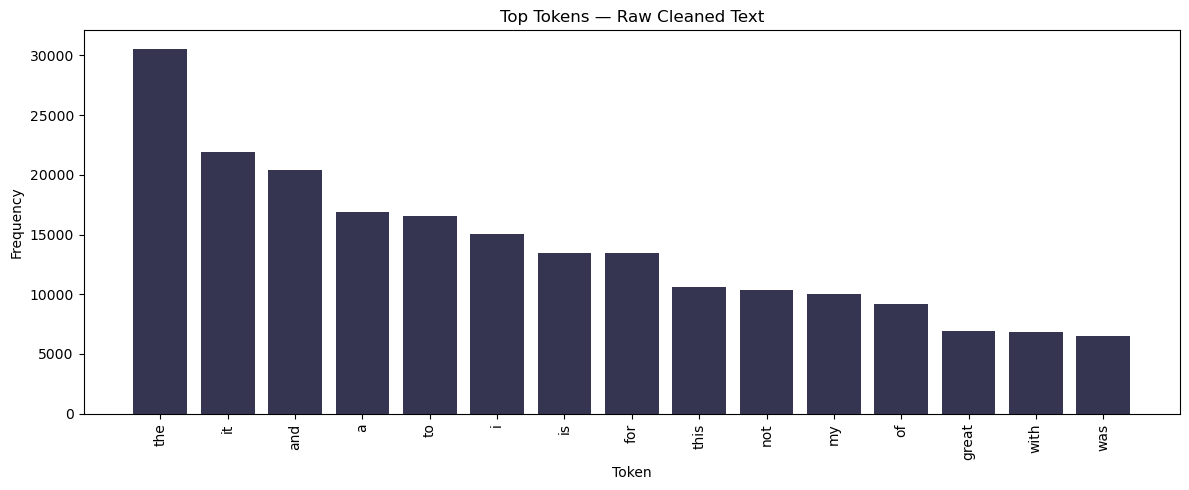

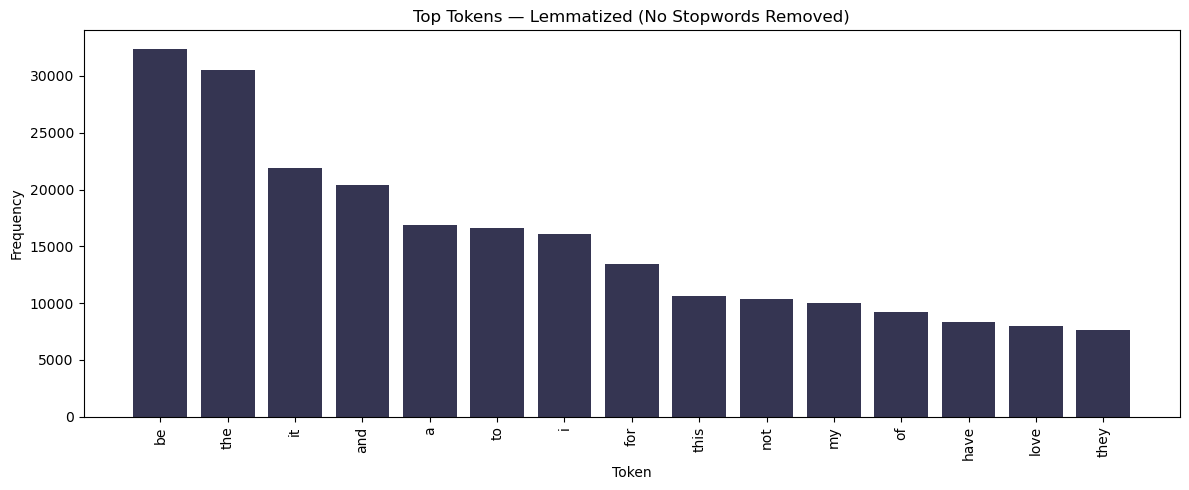

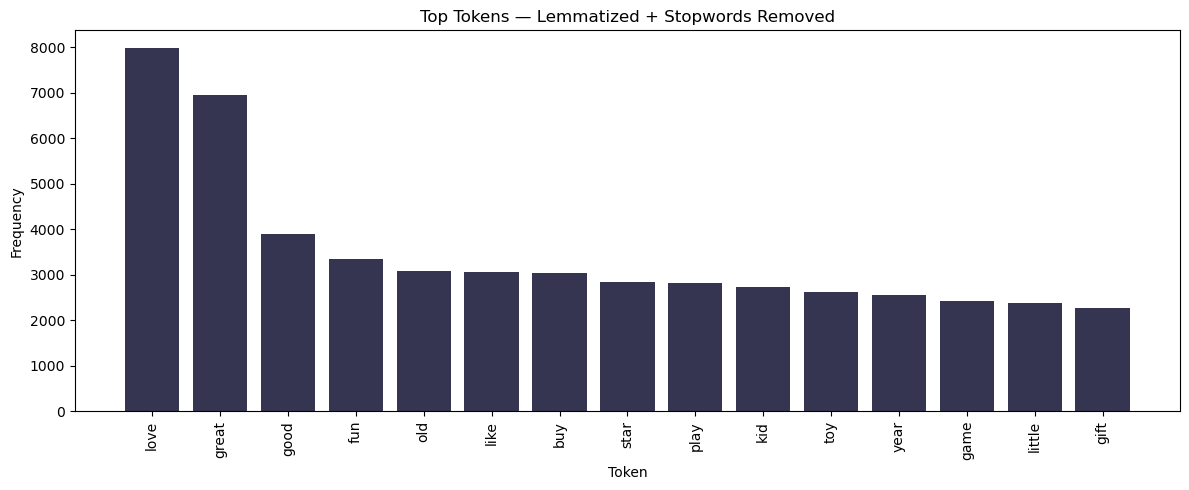

In [34]:
def plot_top_tokens(df, title):
    plt.figure(figsize=(12, 5))
    plt.bar(df["token"], df["count"])
    plt.title(title)
    plt.xticks(rotation=90)
    plt.ylabel("Frequency")
    plt.xlabel("Token")
    plt.tight_layout()
    plt.show()

plot_top_tokens(raw_df, "Top Tokens — Raw Cleaned Text")
plot_top_tokens(lemma_df, "Top Tokens — Lemmatized (No Stopwords Removed)")
plot_top_tokens(final_df, "Top Tokens — Lemmatized + Stopwords Removed")

In [35]:
def total_token_count(series):
    return series.dropna().astype(str).str.split().str.len().sum()

token_counts = pd.DataFrame({
    "Stage": ["Raw cleaned", "Lemmatized only", "Lemmatized + stopwords removed"],
    "Total Tokens": [
        total_token_count(amazon_df["text_raw"]),
        total_token_count(amazon_df["text_lemma_only"]),
        total_token_count(amazon_df["clean_text"])
    ]
})

token_counts

,Stage,Total Tokens
0,Raw cleaned,700566
1,Lemmatized only,700566
2,Lemmatized + stopwords removed,319900


### Observations
- With the removal of stopwords and lemmatising, we can see that more unique words are appearing related to the reviews.
- With inclusion of stopwords and lemmatisation there is a substanial change in number of tokens..
  

## Text Standard Analysis

In [36]:
# Ensure no NaNs in source text
amazon_df["total_review"] = amazon_df["total_review"].fillna("")

# --- Row-level metrics ---
amazon_df["word_count"] = amazon_df["total_review"].apply(
    lambda x: len(str(x).split())
)

amazon_df["reading_time_sec"] = amazon_df["total_review"].apply(
    lambda x: textstat.reading_time(str(x), ms_per_char=14.69) * 60
)

amazon_df["text_standard"] = amazon_df["total_review"].apply(
    lambda x: textstat.text_standard(str(x))
)

# --- Summary table ---
summary_table = (
    amazon_df
    .groupby("output")
    .agg(
        avg_word_count=("word_count", lambda x: np.round(x.mean())),
        avg_reading_time_sec=("reading_time_sec", "mean"),
    )
    .round(2)
)

# Convert seconds to minutes + seconds for display
def format_minutes_seconds(seconds):
    if pd.isna(seconds):
        return ""
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}m {secs}s"

summary_table["avg_reading_time"] = summary_table["avg_reading_time_sec"].apply(
    format_minutes_seconds
)

summary_table = summary_table.drop(columns="avg_reading_time_sec")

# Most common text standard per class
text_standard_summary = (
    amazon_df
    .groupby("output")["text_standard"]
    .agg(lambda s: s.value_counts().idxmax())
    .to_frame("most_common_text_standard")
)

summary_table = summary_table.join(text_standard_summary)

# Human-readable labels
summary_table.index = summary_table.index.map({
    0: "Negative",
    1: "Positive"
})

# Rename columns
summary_table = summary_table.rename(columns={
    "avg_word_count": "Avg Word Count",
    "avg_reading_time": "Average Reading Time",
    "most_common_text_standard": "Text Level"
})

summary_table

,Avg Word Count,Average Reading Time,Text Level
output,,,
Negative,43.0,2m 39s,7th and 8th grade
Positive,33.0,2m 0s,8th and 9th grade


### Observations
- There are only minor variance between the two polarities
- Negative has a higher avg word count which correlates to the slightly higher reading time. More to express when frustrated?
- Interesting to see the text level difference between the two polarities. Potentially less articulating when we are emotional?
  

## Word Cloud

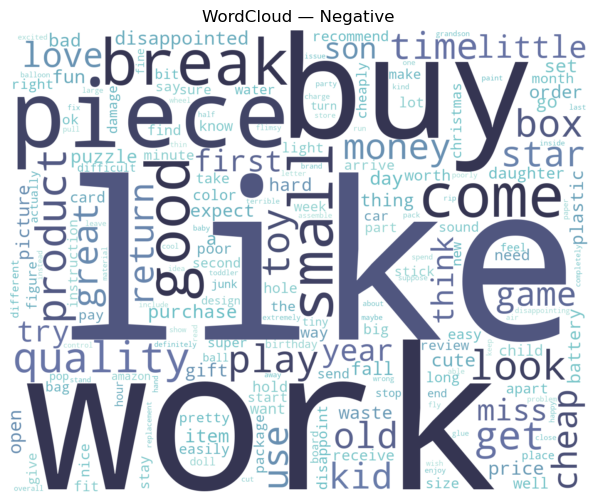

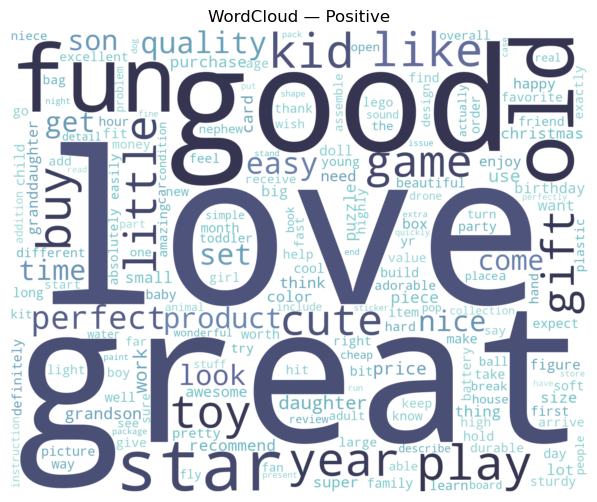

In [37]:
import matplotlib.colors as mcolors

# Your slide palette (ordered dark -> light)
PALETTE = ["#353552", "#6875a7", "#6abec5", "#afe0d9"]  # excluded "#f5f5f5" so words don't vanish on white bg

# Build a smooth gradient colormap from your palette
CMAP = mcolors.LinearSegmentedColormap.from_list("slide_grad", PALETTE, N=256)

label_map = {0: "Negative", 1: "Positive"}

def word_freq(series):
    tokens = " ".join(series.dropna().astype(str)).split()
    return Counter(tokens)

# Create a color_func that maps font_size -> gradient color
def make_size_gradient_color_func(cmap, min_size=10, max_size=140, jitter=0.25, gamma=0.85):
    """
    - Larger words -> darker colors
    - Smaller words -> lighter colors
    - jitter adds subtle hue variety
    - gamma adjusts how quickly colors get darker with size (<1 darkens earlier)
    """
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        # Normalize font size to [0, 1]
        t = (font_size - min_size) / (max_size - min_size)
        t = max(0.0, min(1.0, t))

        # Larger words should be darker:
        # t=0 (small) -> 1.0 (light end), t=1 (large) -> 0.0 (dark end)
        v = 1.0 - (t ** gamma)

        # Add small deterministic jitter per word for variety (still stable run-to-run)
        j = ((hash(word) % 1000) / 1000.0 - 0.5) * 2 * jitter
        v = max(0.0, min(1.0, v + j))

        r, g, b, _ = cmap(v)
        return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"
    return color_func

color_func = make_size_gradient_color_func(CMAP, min_size=10, max_size=140, jitter=0.18, gamma=0.75)

for label, group in amazon_df.groupby("output"):
    label_name = label_map.get(label, str(label))

    freqs = word_freq(group["clean_text"])
    if not freqs:
        continue

    wc = WordCloud(
        width=1500,
        height=1200,
        background_color="white",
        max_words=200,
        collocations=False,
        prefer_horizontal=0.9,
        relative_scaling=0.5,  # helps separate large vs small word sizing
        color_func=color_func
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {label_name}")
    plt.show()

### Observations
- Frequency of words was unexpected, we see observations of words like "like", "good", "great" & love appearing in the negative assortment of words.
- Could this be due to rating 3 inclusions?
- is this an earlier indicator that sentiment maybe be harder to model?
  

In [38]:
#text blob was complaining about nans previewing to identify why
amazon_df[amazon_df.isna().any(axis=1)]

,rating,text,total_review,output,text_raw,text_lemma_only,clean_text,word_count,reading_time_sec,text_standard
2056,5.0,a+++,a a,1,a a,a a,NaN,2,1.7628,-1th and 0th grade
2117,5.0,👍👍,,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
3030,5.0,👍🏻,,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
3311,5.0,👍,,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
4844,5.0,a,a a,1,a a,a a,NaN,2,1.7628,-1th and 0th grade
4933,5.0,👍,,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
6553,5.0,A+!!!,a a,1,a a,a a,NaN,2,1.7628,-1th and 0th grade
7095,5.0,😁,,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
7784,5.0,:-),,1,NaN,NaN,NaN,0,0.0000,-1th and 0th grade
7805,5.0,A,a a,1,a a,a a,NaN,2,1.7628,-1th and 0th grade


In [39]:
# Drop isna rows from table. looks like emojis were converted to NaN rather than empty cell. We have decided to drop.
amazon_df = amazon_df.dropna(subset=["clean_text"])

## Textblob polarity sentiment analysis and text preview.

In [40]:
amazon_df["polarity"]=amazon_df["clean_text"].apply(lambda x:TextBlob(x).sentiment.polarity)

In [41]:
# Top 5 most NEGATIVE reviews (output = 0)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
top_neg = (
    amazon_df[amazon_df["output"] == 0]
    .sort_values("polarity", ascending=True)   # most negative first
    .head(5)[["rating", "text","clean_text", "polarity"]]
)

# Top 5 most POSITIVE reviews (output = 1)
top_pos = (
    amazon_df[amazon_df["output"] == 1]
    .sort_values("polarity", ascending=False)  # most positive first
    .head(5)[["rating", "text", "clean_text", "polarity"]]
)

display(top_neg)
display(top_pos)

,rating,text,clean_text,polarity
19180,1.0,Terrible experience<br />The price dropped $10 before I received it,stable price terrible experience price drop receive,-1.0
18800,1.0,Does not spray and kids couldn’t slide.,terrible spray kid slide,-1.0
18257,1.0,Horrible - glue gun used to make these?,horrible horrible glue gun,-1.0
19789,1.0,It doesn't even work,horrible item work,-1.0
16698,3.0,The balloons smelled horrible!,pay balloon smell horrible,-1.0


,rating,text,clean_text,polarity
5343,5.0,Perfect for the luau bridal shower I hosted for my friend.,star perfect luau bridal shower host friend,1.0
11545,5.0,"They do stretch out once they have been snapped and worn a few times, but they are perfect for a kids party give away.",perfect kid party away stretch snap wear time perfect kid party away,1.0
13991,4.0,I teach Kindergarten and this is perfect for my word wall. The pictures with the letters help the children with their letters.,look teach kindergarten perfect word wall picture letter help child letter,1.0
5835,5.0,These are perfect to add embelishments for projects. My daughter and I have made several head bands. I would recommend this item.,perfect project perfect add embelishment project daughter head band recommend item,1.0
13936,4.0,excellent,need excellent,1.0


### Observations
- textblob demonstrated that high polarity sample of text were weighted to words that are contextually negative or positive. i.e terrible, horrible, perfect, excellent.
- Different compared to the frequency of text and would be interesting to compare model results with this polarity sample.
  

# Train Test Split

In [42]:
# Features and Labels
X = amazon_df['clean_text']
y = amazon_df['output']

# Apply a train-test split
X_train_text, X_valid_text, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Vectorising

In [46]:
# Count Vectorizer
counts = CountVectorizer(token_pattern=r"(?u)\b\w\w+\b")
counts_A = counts.fit_transform(X_train_text)

In [47]:
# TF-IDF (word)
tfidfword = TfidfVectorizer(
    token_pattern=r"(?u)\b\w\w+\b",
    analyzer="word"
)
tfidfword_A = tfidfword.fit_transform(X_train_text)

In [48]:
# TF-IDF (ngrams 2-3)
tfidfngram = TfidfVectorizer(
    token_pattern=r"(?u)\b\w\w+\b",
    analyzer="word",
    ngram_range=(2, 3)
)
tfidfngram_A = tfidfngram.fit_transform(X_train_text)

### Feature Representations Tested

The following text vectorisation approaches were evaluated:

1. CountVectorizer (unigrams)
2. TF-IDF Vectorizer (unigrams)
3. TF-IDF Vectorizer (bigrams)

These approaches were compared based on predictive performance, sparsity, and interpretability.

In [49]:
def vector_stats(X, name):
    total_features = X.shape[1]
    non_zero = X.nnz if hasattr(X, "nnz") else (X != 0).sum()
    density = non_zero / (X.shape[0] * X.shape[1])
    
    return {
        "Vectorizer": name,
        "Features": total_features,
        "Non-zero entries": non_zero,
        "Density": round(density, 6)
    }

stats = []

stats.append(vector_stats(counts_A, "Count (Unigram)"))
stats.append(vector_stats(tfidfword_A, "TF-IDF (Unigram)"))
stats.append(vector_stats(tfidfngram_A, "TF-IDF (Bigram)"))

pd.DataFrame(stats)

,Vectorizer,Features,Non-zero entries,Density
0,Count (Unigram),13987,212769,0.000952
1,TF-IDF (Unigram),13987,212769,0.000952
2,TF-IDF (Bigram),351409,451266,0.000080


## Observations
- Dimenionality of brigrams increase substantially.
- Bigrams are extremely sparse and seem to very rarely appear meaning limited number of signals.
- Potential sign to drop Bigram for this analysis
  

# Modelling

A Pipeline was created to run the 2 vectorizers and 3 models to determine a best performance through a table. 

The metrics used:

- Accuracy
- Precision
- Recall
- F1

### Building the modelling pipline and comparison table

In [50]:
def eval_pipe(name, pipe, X_train, y_train, X_valid, y_valid):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_valid, y_pred, average="weighted")

    return {
        "Vectorizer + Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f1, 4)
    }

vectorizers = {
    "Count (uni)": CountVectorizer(ngram_range=(1,1)),
    "TF-IDF (uni)": TfidfVectorizer(ngram_range=(1,1)),
}

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(),
}

results = []

for v_name, vect in vectorizers.items():
    for m_name, model in models.items():
        pipe = Pipeline([
            ("vect", vect),
            ("model", model)
        ])
        name = f"{v_name} + {m_name}"
        results.append(eval_pipe(name, pipe, X_train_text, y_train, X_valid_text, y_valid))

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Vectorizer + Model,Accuracy,Precision,Recall,F1
5,TF-IDF (uni) + LinearSVC,0.9024,0.8992,0.9024,0.8993
0,Count (uni) + LogReg,0.9024,0.8992,0.9024,0.8991
3,TF-IDF (uni) + LogReg,0.9014,0.8999,0.9014,0.8950
1,Count (uni) + MultinomialNB,0.8961,0.8924,0.8961,0.8922
2,Count (uni) + LinearSVC,0.8866,0.8836,0.8866,0.8847
4,TF-IDF (uni) + MultinomialNB,0.8391,0.8640,0.8391,0.7994


## Creating a Confusion Matrix, Precision/Recall and ROC Chart

In [51]:
def get_scores(pipe, X):
    """
    Returns a continuous score for the positive class.
    Uses predict_proba if available, otherwise decision_function.
    """
    model = pipe.named_steps["model"]

    if hasattr(model, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return pipe.decision_function(X)
    else:
        raise ValueError("Model does not support predict_proba or decision_function.")

In [52]:
# Evaluation plot function
def plot_eval_curves(pipe, X_valid, y_valid, title="Model evaluation"):
    y_pred = pipe.predict(X_valid)
    scores = get_scores(pipe, X_valid)

    ## Metrics
    cm = confusion_matrix(y_valid, y_pred)
    cm_percent = cm / cm.sum() * 100

    prec, rec, _ = precision_recall_curve(y_valid, scores)
    ap = average_precision_score(y_valid, scores)

    fpr, tpr, _ = roc_curve(y_valid, scores)
    auc = roc_auc_score(y_valid, scores)

    # Prepare annotations: count + percentage
    annot = np.array([
        [f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1) Confusion Matrix (slide palette)
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=slide_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("True label")
    axes[0].set_ylabel("Predicted label")

    # 2) Precision–Recall Curve
    axes[1].plot(
        rec,
        prec,
        color=SLIDE_PALETTE[2],
        linewidth=2
    )
    axes[1].set_title(f"2-class Precision–Recall (AP = {ap:.2f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    # 3) ROC Curve
    axes[2].plot(
        fpr,
        tpr,
        color=SLIDE_PALETTE[1],
        linewidth=2,
        label=f"AUC = {auc:.2f}"
    )
    axes[2].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color=SLIDE_PALETTE[0],
        alpha=0.7
    )
    axes[2].set_title("Receiver Operating Characteristic")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].legend(loc="lower right")

    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

### TF-IDF LinearSVC - CM, PR, ROC chart analysis

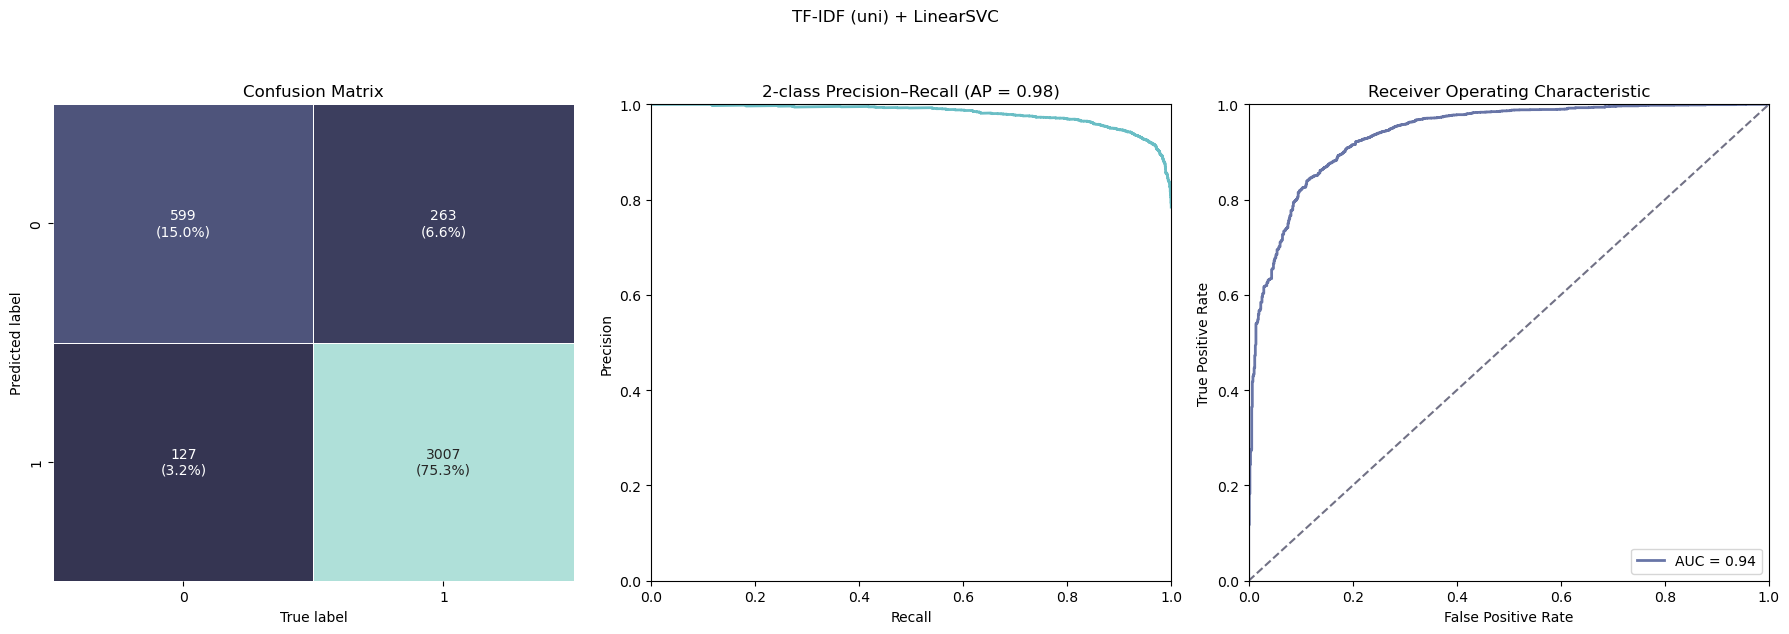

In [53]:
best_pipe = Pipeline([
    ("vect", TfidfVectorizer(ngram_range=(1,1))),
    ("model", LinearSVC())
])

best_pipe.fit(X_train_text, y_train)

plot_eval_curves(best_pipe, X_valid_text, y_valid, title="TF-IDF (uni) + LinearSVC")

### Count LogReg - CM, PR, ROC chart analysis

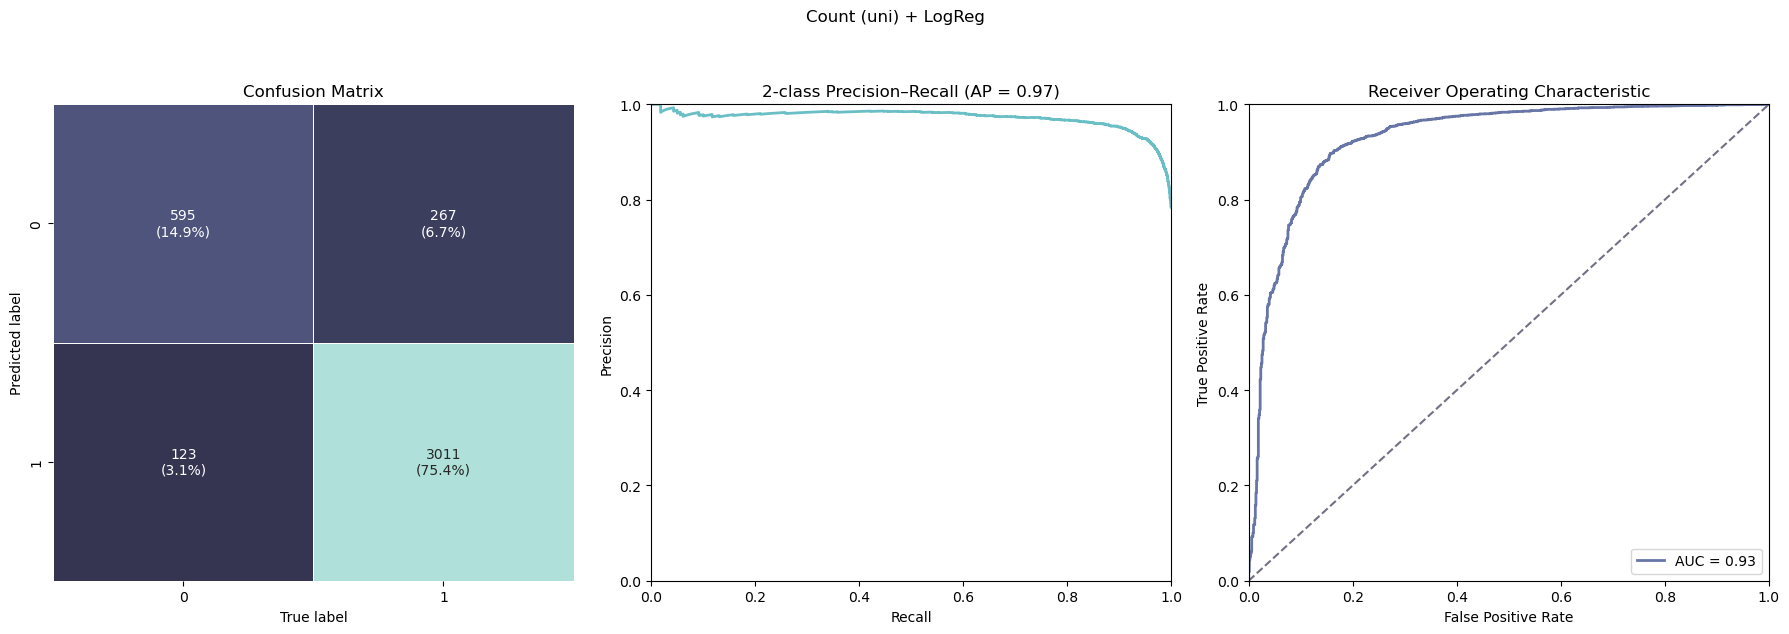

In [54]:
second_pipe = Pipeline([
    ("vect", CountVectorizer(ngram_range=(1,1))),
    ("model", LogisticRegression(max_iter=1000))
])

second_pipe.fit(X_train_text, y_train)

plot_eval_curves(second_pipe, X_valid_text, y_valid, title="Count (uni) + LogReg")

### Observations
- Comparing the CM, PR and ROC chart with quantitative results, confirming TF-IDF unigram features with LinearSVC as the most robust and reliable model for this task.
  

### Positive and Negative Sentiment Features importance
The table shows a comparison of positive and negative features and importance.

In [55]:
# Get feature names from the vectorizer
feature_names = best_pipe.named_steps["vect"].get_feature_names_out()

# Get coefficients from LinearSVC
coefs = best_pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

TOP_N = 15

top_positive = (
    coef_df.sort_values("coefficient", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_negative = (
    coef_df.sort_values("coefficient")
    .head(TOP_N)
    .reset_index(drop=True)
)

polarity_table = pd.DataFrame({
    "Positive feature": top_positive["feature"],
    "Positive coefficient": top_positive["coefficient"].round(4),
    "Negative feature": top_negative["feature"],
    "Negative coefficient": top_negative["coefficient"].round(4),
})

polarity_table

,Positive feature,Positive coefficient,Negative feature,Negative coefficient
0,love,3.5532,disappointed,-3.9993
1,perfect,3.4199,disappointing,-3.0341
2,awesome,2.6301,poor,-2.6885
3,great,2.5817,return,-2.5666
4,perfectly,2.0071,waste,-2.3796
5,fantastic,1.9300,cheaply,-2.2184
6,adorable,1.6989,meh,-2.2134
7,nicely,1.6683,break,-1.9598
8,exactly,1.6385,poorly,-1.9121
9,highly,1.5926,junk,-1.9046


### Observation
- Features for both polarites are as expected where the verbage has postive or negative associations. Similiar to what we say in the textblob text preview.

In [56]:
y_pred = best_pipe.predict(X_valid_text)

error_df = pd.DataFrame({
    "true_label": y_valid,
    "pred_label": y_pred,
    "clean_text": X_valid_text
}, index=X_valid_text.index)
error_df = error_df.join(amazon_df[["total_review", "rating"]])

In [57]:
false_positives = error_df[
    (error_df["true_label"] == 0) &
    (error_df["pred_label"] == 1)
].head(5)

false_positives[["total_review", "rating", "true_label", "pred_label"]]

,total_review,rating,true_label,pred_label
16332,difficult but fun a difficult puzzle pieces are not interlocking the puzzle pieces are very thin not the usual thickness of most puzzles this puzzle will take some time to complete i do jigsaw puzzles all the time,3.0,0,1
16891,just okay my year old begged for these i gave in and it ended pretty much how i expected they are just dumped out all over the floor tossed around and maybe a few are put together the year olds favorite thing is to do is throw them in the air and pretend it is raining i have managed to get the kids to sort them by color but they are unlikely at this age to put them together in any meaningful way without instruction,3.0,0,1
18252,antenna signal range booster parabolic these are a really stupid design the brackets that attach to the antennas tozo antenna signal range booster parabolic these are a really stupid design the brackets that attach to the antennas are too far apart vertically and too far out from the curved surface resulting in a situation where you cannot put your antennas anywhere near vertical because the booster is bumping the body of the rc if they had put the antenna brackets lower and closer together the reflector could be on the antennas and still allow you to tilt the antennae straight up vertical i really do not think the designers of this unit actually tested this product on an actual remote control unit before mass producing and shipping,1.0,0,1
17769,not a fan i am not a big fan of this the toy is small and definitely for older children my husband had to put it together for my kids who are and they broke it many times and kept coming back for help to fix it,2.0,0,1
16266,good quality but no grip on bottom i have a month old who does physical therapy exercises for torticollis i chose this item because of great reviews variety of shapes and size of cushions the quality of material and density of cushions is great the downside is that these slip and slide on any surface rug play mat wood i would not recommend for any parent looking for some type of secure cushion to have kids prop against or do exercises on for parents who just want fun cushions for kids to roll around with then this is it,3.0,0,1


In [58]:
false_negatives = error_df[
    (error_df["true_label"] == 1) &
    (error_df["pred_label"] == 0)
].head(5)

false_negatives[["total_review", "rating", "true_label", "pred_label"]]

,total_review,rating,true_label,pred_label
14468,needs air the pamphlet included talks about is thr sand moves to quick or to slow and a regulator on how to fix it but unfortunately this is not included and mine tends to move to fast the smaller versions are more disappointing than larger versions which is sad as it is mesmorong and calming and great for desk environment if it works,4.0,1,0
8116,my son loves this and it is not cheaply made my son loves this and it is not cheaply made we bought him a different brand before and it did not last a day as he is really rough on his toys this is still going strong months later,5.0,1,0
13534,bath time is more fun now the toys are just as pictured bright rubber animals my baby months old likes them but she was frustrated at first as she had hard time holding them now she learned to use both her little hands and does not complain anymore the only thing i may not like is a little chemical smell but i hope it is not harmful and will disappear soon,4.0,1,0
12867,looks great looks just like the picture we like this version better than the with the fire and ugly dresslol,5.0,1,0
622,not messy i am a big fan of play doh so i decided to give their slime pack a try my year old daughter said this slime is the least sticky and messy,5.0,1,0


### Observation
- Looking at the above samples of False Positive and False Negatives. We can see this ties back to our original question and business case. We are able through the sentiment analysis to identify missclassied cases.
- false negative 1 shows that they were disapointed in the product compared to another whie the respondant rated it 4.
- The 3rd false negative shows that there might be a product defect.
- While the remaining three examples are examples of customer using a negative "past" to compare to this experience. Likely pulled in here due to the negative verbage.
  

# Conclusion
- TF-IDF unigrame + LinearSVC was the best model to use in the predicitive analysis.
- It gave the strongest F1 score at 0.899 and a AP rate of 0.97 and AUC of 0.94.
- We can see that it also performed quite well to find missclassifications in reviews and provides information for further deep diving.
